In [16]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
from codes import OpticalData

optical = OpticalData(ew_filepath="/Users/hintont/Dev/projects/Ridgecrest/data/EW_Ridgecrest_1m_utm.tif", ns_filepath="/Users/hintont/Dev/projects/Ridgecrest/data/NS_Ridgecrest_1m_utm.tif", verbose=True)
optical = optical.decimate(10)
optical = optical.clear_nan()

Init OpticalData with {'ew_filepath': '/Users/hintont/Dev/projects/Ridgecrest/data/EW_Ridgecrest_1m_utm.tif', 'ns_filepath': '/Users/hintont/Dev/projects/Ridgecrest/data/NS_Ridgecrest_1m_utm.tif'}
Importing TIF files: /Users/hintont/Dev/projects/Ridgecrest/data/EW_Ridgecrest_1m_utm.tif /Users/hintont/Dev/projects/Ridgecrest/data/NS_Ridgecrest_1m_utm.tif
Imported EW data shape: (53626, 48648)
Imported NS data shape: (53626, 48648)

Decimating EW optical...
Decimating NS optical...
Decimated

Clearing NaNs...
... cleared.


In [18]:
from codes import Fault
fault = Fault(filepath="/Users/hintont/Dev/projects/Ridgecrest/data/fault_trace.shp", crs=optical.ew.rio.crs)

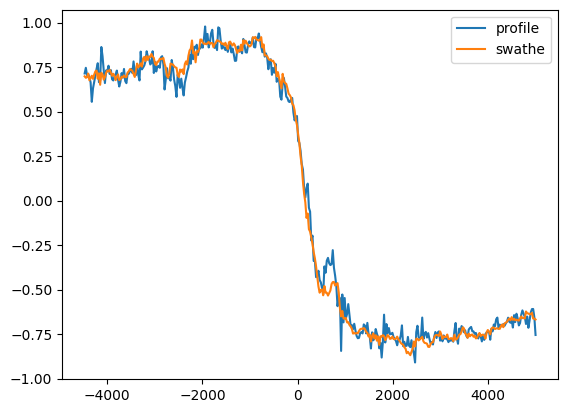

In [21]:
import matplotlib.pyplot as plt

profile = fault.gen_profiles(n_in_swathe=1)[0]
swathe = fault.gen_profiles(n_in_swathe=20)[0]

profile = optical.evaluate_profile(profile)
swathe = optical.evaluate_profile(swathe)

plt.plot(profile.xs, profile.displacements[1], label="profile")
plt.plot(swathe.xs, swathe.displacements[1], label="swathe")
plt.legend()

In [11]:
from codes import Fault
fault = Fault(filepath="/Users/hintont/Dev/projects/Ridgecrest/data/fault_trace.shp", crs=optical.ew.rio.crs)
profiles = fault.gen_profiles()
profiles = optical.evaluate_profiles(profiles)

Plotting...
... plotted.


[<Figure size 700x600 with 2 Axes>,
 <Axes: xlabel='Latitude (˚)', ylabel='Longitude (˚)'>]

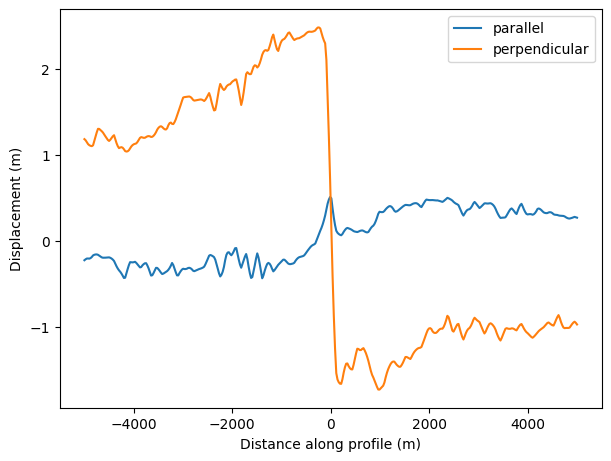

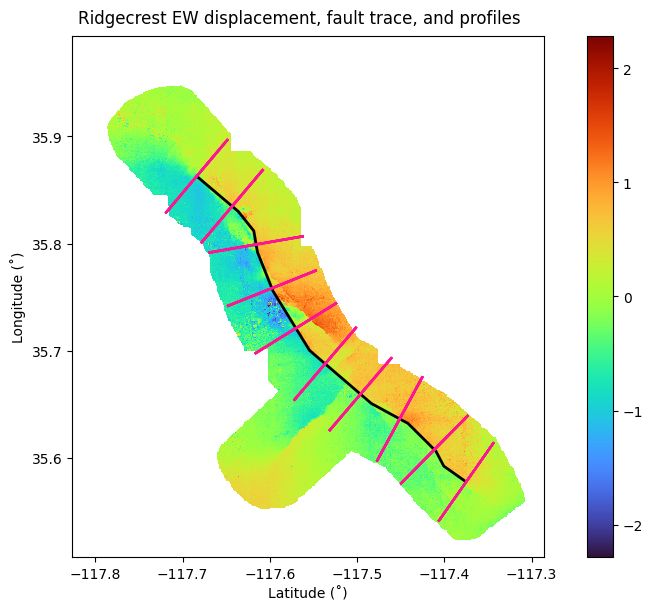

In [12]:
profiles[3].plot()
optical.plot_ew(title="Ridgecrest EW displacement, fault trace, and profiles", fault=fault, profiles=profiles)